In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("train (2).csv", usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [3]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

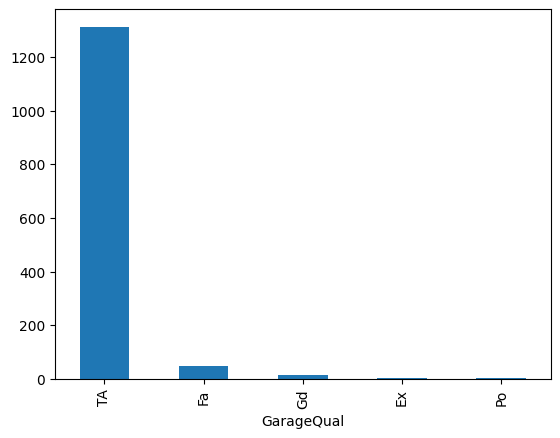

In [4]:
df['GarageQual'].value_counts().plot.bar()

In [5]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

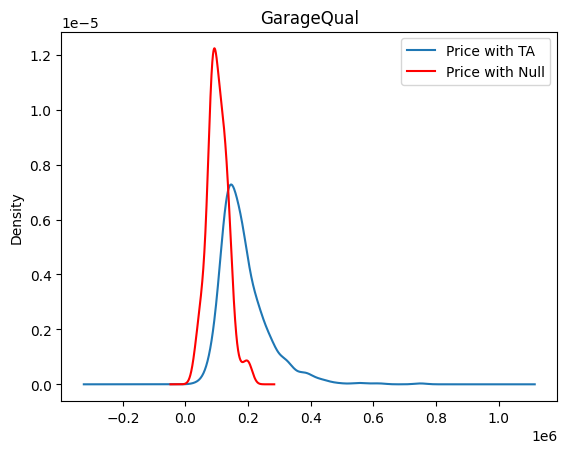

In [6]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, label='Price with TA')

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='r', label='Price with Null')

ax.legend()

plt.title("GarageQual")
plt.show()

In [7]:
temp = df[df['GarageQual'] == 'TA']['SalePrice']

In [8]:
df['GarageQual'].fillna('TA')

0       TA
1       TA
2       TA
3       TA
4       TA
        ..
1455    TA
1456    TA
1457    TA
1458    TA
1459    TA
Name: GarageQual, Length: 1460, dtype: object

In [9]:
print(df['GarageQual'].value_counts())

GarageQual
TA    1311
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64


<Axes: xlabel='GarageQual'>

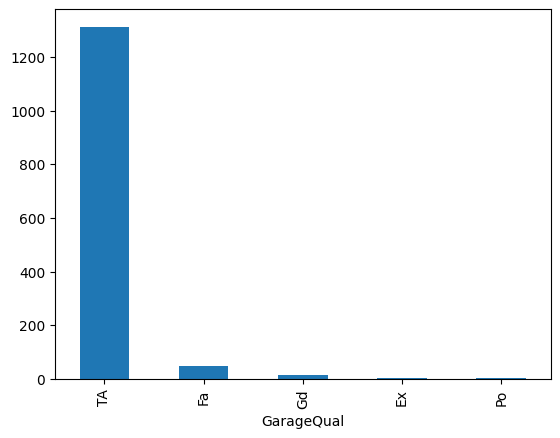

In [10]:
df['GarageQual'].value_counts().plot(kind='bar')

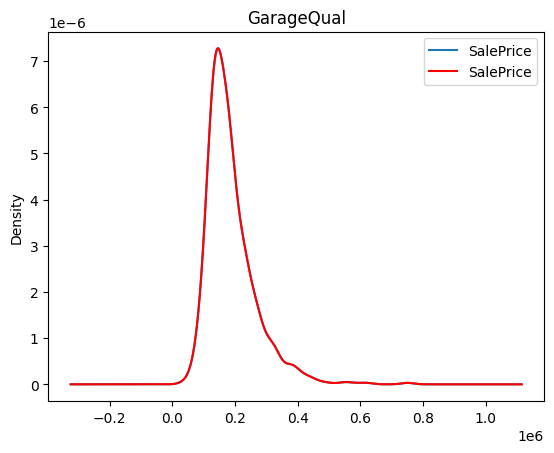

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='r')

ax.legend()

plt.title("GarageQual")
plt.show()

<Axes: xlabel='FireplaceQu'>

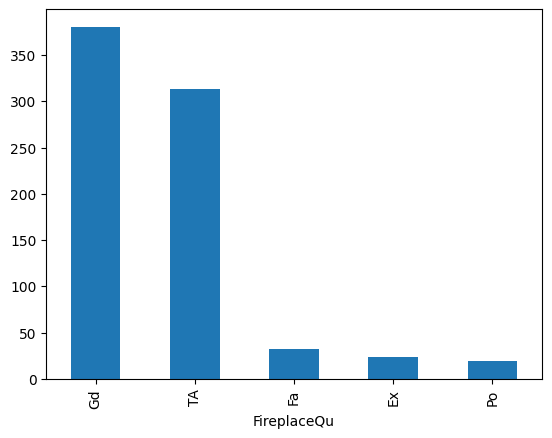

In [12]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [13]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

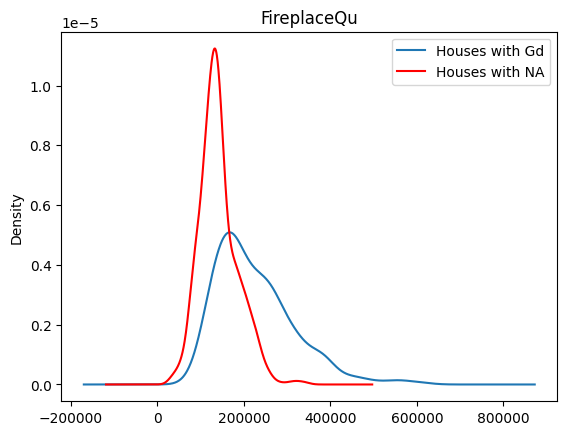

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, label='Houses with Gd')

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='r', label='Houses with NA')

ax.legend()

plt.title("FireplaceQu")
plt.show()

In [15]:
temp = df[df['FireplaceQu'] == 'Gd']['SalePrice']

In [16]:
df['FireplaceQu'] = df['FireplaceQu'].fillna('Gd')

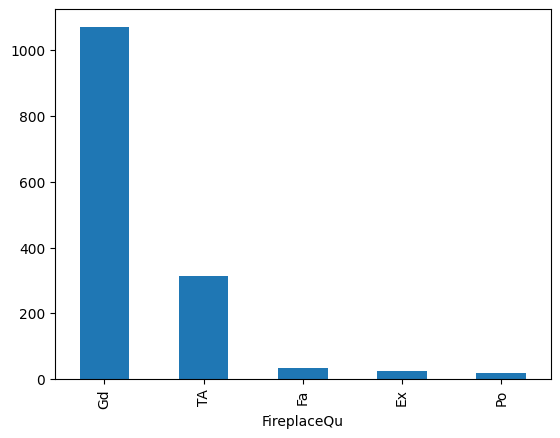

In [17]:
df['FireplaceQu'].value_counts().plot(kind='bar')
plt.show()

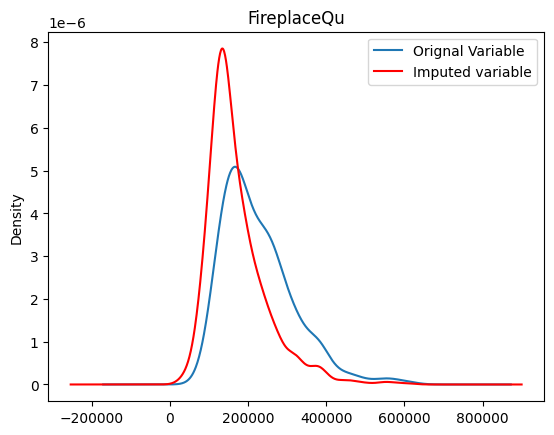

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax, label='Orignal Variable')

# distribution of the variable after imputation
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, color='r', label='Imputed variable')

ax.legend()
plt.title("FireplaceQu")
plt.show()

## Let's do with SKlearn

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['SalePrice']), df['SalePrice'], test_size=0.2)

In [20]:
from sklearn.impute import SimpleImputer

In [23]:
imputer = SimpleImputer(strategy='most_frequent')

In [24]:
X_train = imputer.fit(X_train)
X_test = imputer.transform(X_test)

In [25]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)